## Predict Insurance Charges, Pricing Models

In [2]:
pwd

'C:\\Users\\91831'

In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error

In [4]:
df = pd.read_csv("insurance.csv")

print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [5]:
print(df.shape)

print(df.info())

print(df.describe())

(1338, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.

In [6]:
print(df.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


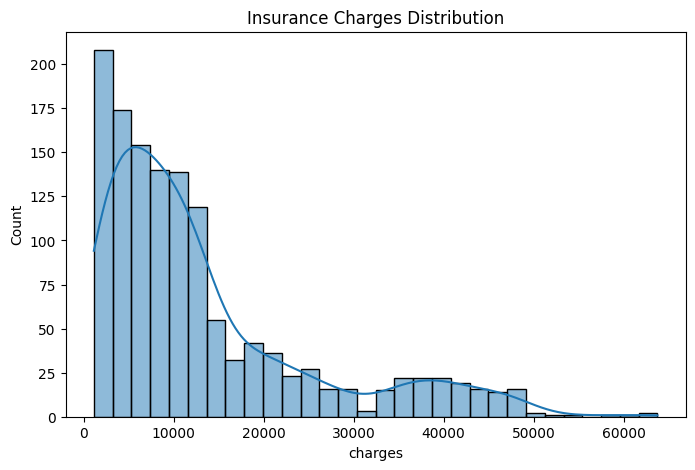

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df["charges"], kde=True)
plt.title("Insurance Charges Distribution")
plt.show()

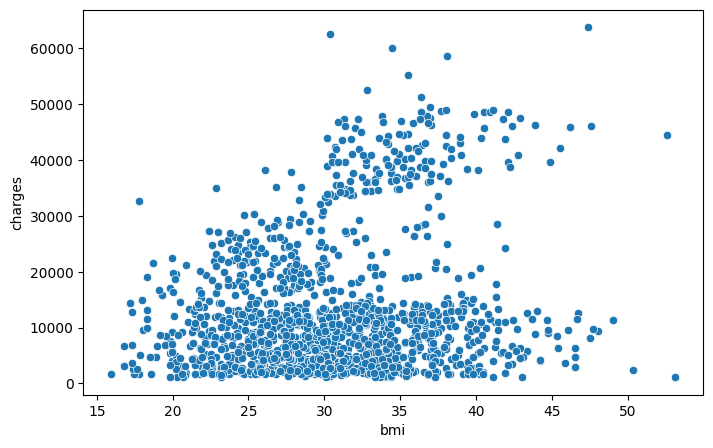

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="bmi", y="charges", data=df)
plt.show()

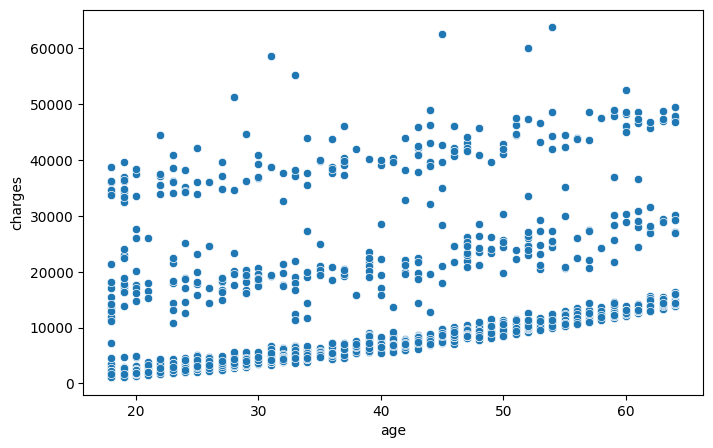

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="age", y="charges", data=df)
plt.show()

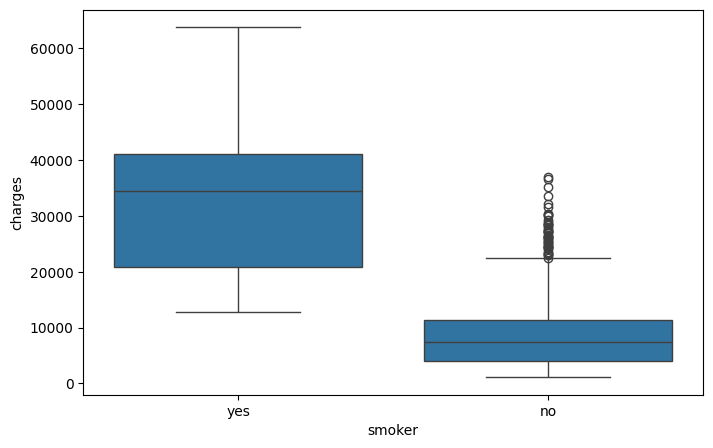

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x="smoker", y="charges", data=df)
plt.show()

In [13]:
le = LabelEncoder()

df["sex"] = le.fit_transform(df["sex"])
df["smoker"] = le.fit_transform(df["smoker"])
df["region"] = le.fit_transform(df["region"])

In [14]:
print(df.head())

   age  sex     bmi  children  smoker  region      charges
0   19    0  27.900         0       1       3  16884.92400
1   18    1  33.770         1       0       2   1725.55230
2   28    1  33.000         3       0       2   4449.46200
3   33    1  22.705         0       0       1  21984.47061
4   32    1  28.880         0       0       1   3866.85520


In [15]:
X = df.drop("charges", axis=1)

In [16]:
y = df["charges"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [18]:
print(X_train.shape)
print(X_test.shape)

(1070, 6)
(268, 6)


In [19]:
lr = LinearRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [25]:
print("Linear Regression")

print("R2 Score:",r2_score(y_test, lr_pred))

print("MAE:",mean_absolute_error(y_test, lr_pred))

Linear Regression
R2 Score: 0.7833463107364539
MAE: 4186.508898366432


In [26]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [27]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [28]:
print("Random Forest")

print("R2 Score:",r2_score(y_test, rf_pred))

print("MAE:",mean_absolute_error(y_test, rf_pred))

Random Forest
R2 Score: 0.8642606273649586
MAE: 2533.674643617756


In [29]:
results = pd.DataFrame({"Model": ["Linear Regression","Decision Tree","Random Forest"],
"R2 Score": [r2_score(y_test, lr_pred),r2_score(y_test, dt_pred),r2_score(y_test, rf_pred)
    ]
})

print(results)

               Model  R2 Score
0  Linear Regression  0.783346
1      Decision Tree  0.684357
2      Random Forest  0.864261


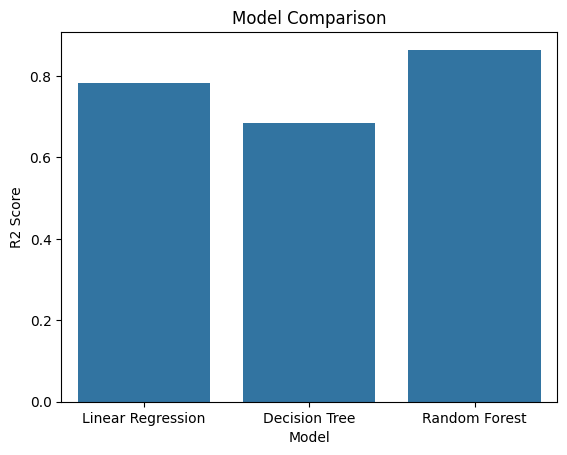

In [33]:
sns.barplot(x="Model",y="R2 Score",data=results)
plt.title("Model Comparison")
plt.show()

In [34]:
import joblib

joblib.dump(rf,"insurance_model.pkl")
print("Model Saved")

Model Saved


In [35]:
model = joblib.load("insurance_model.pkl")

In [36]:
sample = pd.DataFrame({
    "age":[25],
    "sex":[1],
    "bmi":[28.5],
    "children":[0],
    "smoker":[0],
    "region":[2]
})

In [38]:
prediction = model.predict(sample)
print("Predicted Insurance Charge:",prediction[0])

Predicted Insurance Charge: 2507.292831499999


In [39]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

    Feature  Importance
4    smoker    0.608618
2       bmi    0.216291
0       age    0.134554
3  children    0.020199
5    region    0.013926
1       sex    0.006412


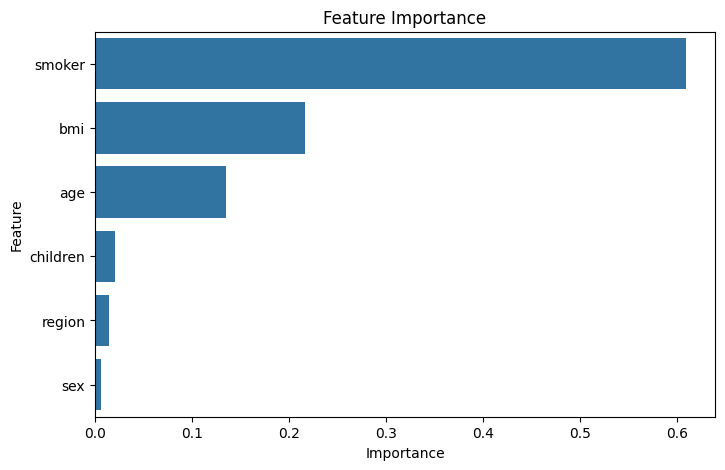

In [40]:
plt.figure(figsize=(8,5))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)
plt.title("Feature Importance")
plt.show()

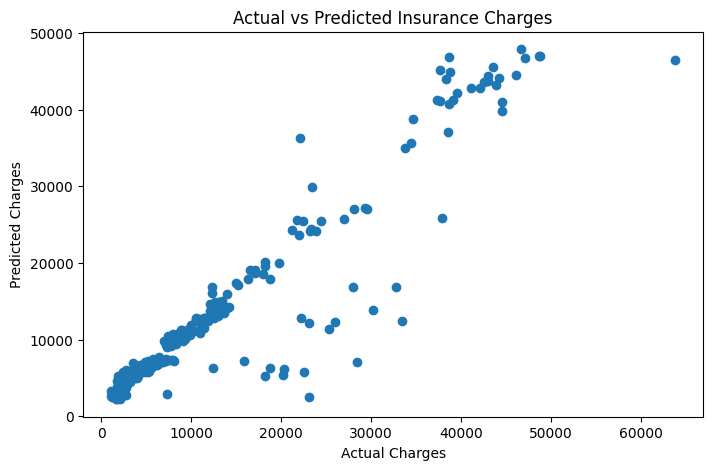

In [4]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, best_pred)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")

plt.show()

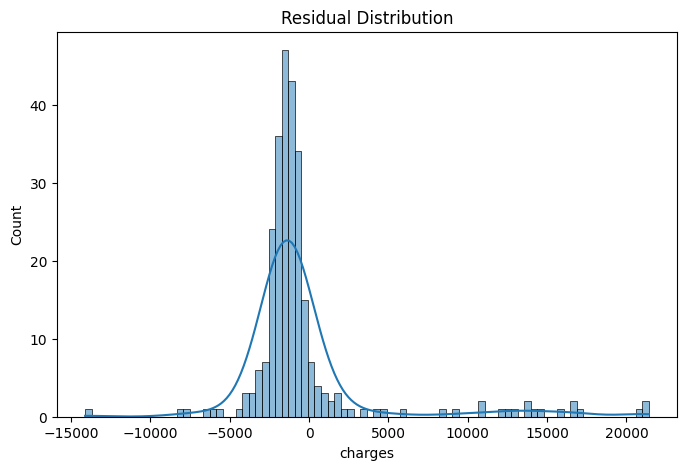

In [5]:
residuals = y_test - best_pred

plt.figure(figsize=(8,5))

sns.histplot(residuals, kde=True)

plt.title("Residual Distribution")

plt.show()

In [6]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "R2 Score": [
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, rf_pred),
        r2_score(y_test, best_pred)
    ]
})

print(results)

                 Model  R2 Score
0    Linear Regression  0.783346
1        Decision Tree  0.684357
2        Random Forest  0.864261
3  Tuned Random Forest  0.872506


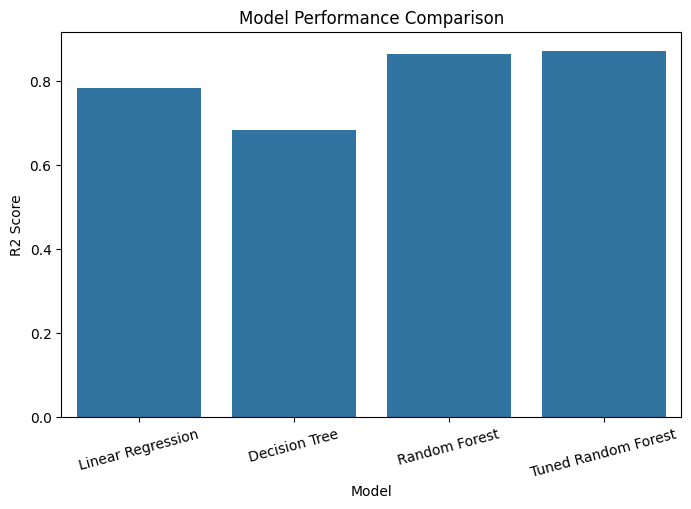

In [7]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="R2 Score",
    data=results
)

plt.title("Model Performance Comparison")

plt.xticks(rotation=15)

plt.show()

In [8]:
import joblib

joblib.dump(
    best_model,
    "insurance_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [9]:
loaded_model = joblib.load(
    "insurance_model.pkl"
)

In [10]:
sample = pd.DataFrame({
    "age": [25],
    "sex": [1],
    "bmi": [28.5],
    "children": [0],
    "smoker": [0],
    "region": [2]
})

prediction = loaded_model.predict(sample)

print(
    "Predicted Insurance Charge: $",
    round(prediction[0], 2)
)

Predicted Insurance Charge: $ 4615.77


In [11]:
best_score = r2_score(y_test, best_pred)

print("\nProject Summary")
print("="*40)
print("Best Model : Tuned Random Forest")
print("R2 Score   :", round(best_score,4))
print("Model Saved Successfully")


Project Summary
Best Model : Tuned Random Forest
R2 Score   : 0.8725
Model Saved Successfully


In [12]:


params = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, 15]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=params,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 5, 'n_estimators': 100}


In [14]:
best_pred = best_model.predict(X_test)

print("Tuned Random Forest R2 Score:")
print(r2_score(y_test, best_pred))

Tuned Random Forest R2 Score:
0.8725060366590471


In [15]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_model,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:")
print(scores)

print("Average Score:")
print(scores.mean())

Cross Validation Scores:
[0.8813983  0.80035262 0.89266915 0.84285184 0.87061676]
Average Score:
0.8575777314639872


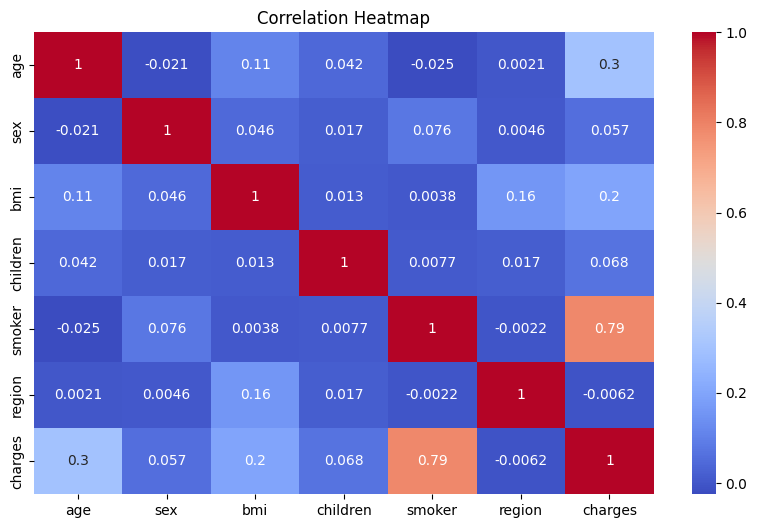

In [16]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

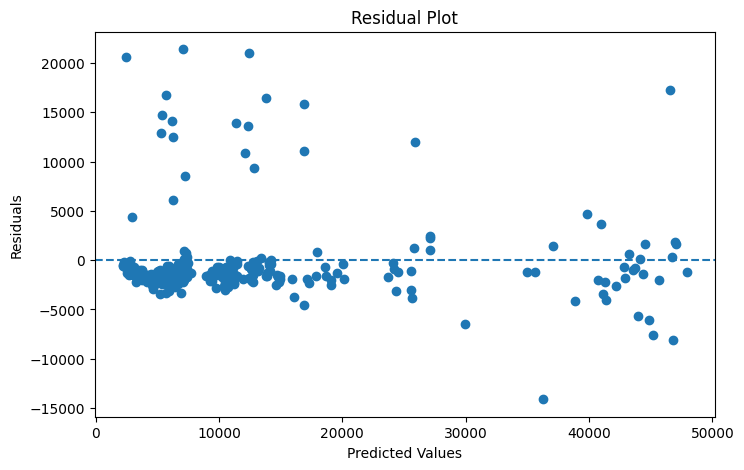

In [17]:
residuals = y_test - best_pred

plt.figure(figsize=(8,5))

plt.scatter(best_pred, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()